In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [10]:
# Kendall's tau for time series analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sktime.datasets import load_daily_delhi_climate
from sktime.dists_kernels import ScipyKernel

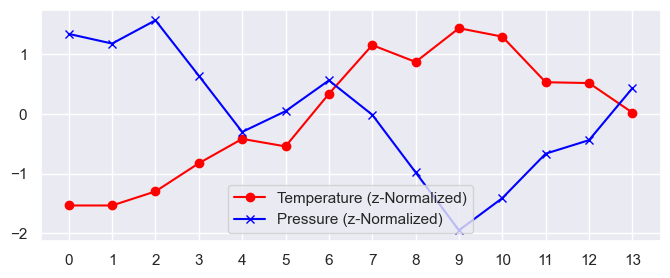

In [12]:
# Time Series Data (Delhi Climate Data)
data = load_daily_delhi_climate()
temperature = data["meantemp"].values[100:120]
pressure = data["meanpressure"].values[100:120]

# Normalize
temperature = (temperature - np.mean(temperature)) / np.std(temperature)
pressure = (pressure - np.mean(pressure)) / np.std(pressure)

sns.set()
plt.figure(figsize=(8, 3))
plt.xticks(range(0, 20), range(0, 20))
plt.plot(temperature, label='Temperature (z-Normalized)', color='red', marker='o')
plt.plot(pressure, label='Pressure (z-Normalized)', color='blue', marker='x')
plt.legend()

In [16]:
# Calculate Kendall's Tau
kernel = ScipyKernel(metric="kendalltau")
result = kernel(temperature.reshape(1, -1), pressure.reshape(1, -1))[0][0]

print(f"Kendall's Tau: {result}")

Kendall's Tau: -0.7513926833493687
